# Store 1 to Store 2 Item Matching using Qdrant Hybrid Search
Match clothing items from store_1 to store_2 using Qdrant vector database with:
- Dense vectors from sentence-transformers
- Sparse vectors from normalized text (lemmas)
- Hybrid search combining both approaches

In [1]:
import pandas as pd
import numpy as np
from glob import glob
import spacy
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    VectorParams,
    PointStruct,
    SparseVector,
    SparseVectorParams,
    SparseIndexParams,
)
from sklearn.feature_extraction.text import TfidfVectorizer

/Users/maksim.rostov/pdev/freelectron/py-ml-dev/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data efficiently
data_dir = "datasets/"

# Load store_1 files
store_1_files = sorted(glob(f"{data_dir}store_1*.csv"))
df_1 = pd.concat([pd.read_csv(f) for f in store_1_files], ignore_index=True)

# Load store_2
df_2 = pd.read_csv(f"{data_dir}store_2.csv", low_memory=False)

print(f"Store 1: {df_1.shape}")
print(f"Store 2: {df_2.shape}")

Store 1: (132561, 31)
Store 2: (75634, 27)


## Step 1: Text Normalization - Extract Lemmas

In [3]:
# Load spaCy for text normalization
nlp_model = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def normalize_text_batch(series, batch_size=1000):
    """Extract lemmatized tokens, removing stopwords and punctuation."""
    results = []
    docs = nlp_model.pipe(series.fillna(""), batch_size=batch_size)
    
    for doc in docs:
        lemmas = [w.lemma_.lower() for w in doc 
                 if not (w.is_stop or w.is_space or w.is_punct)]
        results.append(" ".join(lemmas))
    
    return results

# Normalize both stores
print("Normalizing store 1 items...")
df_1["normalized_text"] = normalize_text_batch(df_1["Item"])

print("Normalizing store 2 items...")
df_2["normalized_text"] = normalize_text_batch(df_2["Item"])

print("\nExample normalized texts:")
for i in range(3):
    print(f"Original: {df_2['Item'].iloc[i]}")
    print(f"Normalized: {df_2['normalized_text'].iloc[i]}\n")

Normalizing store 1 items...
Normalizing store 2 items...

Example normalized texts:
Original: Bonk Breaker Protein (Salted Caramel/Peanut))
Normalized: bonk breaker protein salted caramel peanut

Original: New Balance  Women's Impact Tank (BKH) SM
Normalized: new balance women impact tank bkh sm

Original: New Balance  Women's Impact Tank (BKH) MD
Normalized: new balance women impact tank bkh md



## Step 2: Create Dense Vectors using Sentence Transformers

In [65]:
# Load sentence transformer model
# Using all-MiniLM-L6-v2: fast, good quality, 384 dimensions
dense_model_name = 'all-MiniLM-L6-v2'
embedding_model = SentenceTransformer(dense_model_name)

print(f"Model embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1558.13it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model embedding dimension: 384


In [5]:
# Create dense embeddings for original (non-normalized) text
print("Creating dense embeddings for store 1...")
store_1_embeddings = embedding_model.encode(
    df_1["Item"].fillna("").tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Creating dense embeddings for store 2...")
store_2_embeddings = embedding_model.encode(
    df_2["Item"].fillna("").tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nStore 1 embeddings shape: {store_1_embeddings.shape}")
print(f"Store 2 embeddings shape: {store_2_embeddings.shape}")

Creating dense embeddings for store 1...


Batches: 100%|██████████| 2072/2072 [00:43<00:00, 47.55it/s]


Creating dense embeddings for store 2...


Batches: 100%|██████████| 1182/1182 [00:23<00:00, 50.96it/s]


Store 1 embeddings shape: (132561, 384)
Store 2 embeddings shape: (75634, 384)


## Step 3: Create Sparse Vectors from Normalized Text

In [6]:
# Create TF-IDF vectorizer for sparse representations
tfidf_vectorizer = TfidfVectorizer()

# Fit on combined normalized corpus
all_normalized = pd.concat([df_1["normalized_text"], df_2["normalized_text"]])
tfidf_vectorizer.fit(all_normalized)

# Transform to sparse matrices
store_1_sparse = tfidf_vectorizer.transform(df_1["normalized_text"])
store_2_sparse = tfidf_vectorizer.transform(df_2["normalized_text"])

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Store 1 sparse shape: {store_1_sparse.shape}")
print(f"Store 2 sparse shape: {store_2_sparse.shape}")

Vocabulary size: 12171
Store 1 sparse shape: (132561, 12171)
Store 2 sparse shape: (75634, 12171)


## Step 4: Initialize Qdrant and Create Collection

In [7]:
# Initialize Qdrant client (in-memory)
client = QdrantClient(":memory:")

collection_name = "store_2_items"

# Create collection with both dense and sparse vectors
client.create_collection(
    collection_name=collection_name,
    vectors_config={
        "dense": VectorParams(
            size=embedding_model.get_sentence_embedding_dimension(),
            distance=Distance.COSINE
        )
    },
    sparse_vectors_config={
        "sparse": SparseVectorParams(
            index=SparseIndexParams()
        )
    }
)

print(f"Created collection: {collection_name}")

Created collection: store_2_items


## Step 5: Ingest Store 2 Items into Qdrant

In [60]:
def sparse_matrix_to_sparse_vector(sparse_row):
    """Convert scipy sparse matrix row to Qdrant SparseVector."""
    sparse_row = sparse_row.tocoo()
    return SparseVector(
        indices=sparse_row.col.tolist(),
        values=sparse_row.data.tolist()
    )

# Prepare points for ingestion
print("Preparing store 2 items for ingestion...")
points = []

for idx in range(len(df_2)):
    point = PointStruct(
        id=idx,
        vector={
            "dense": store_2_embeddings[idx].tolist(),
            "sparse": sparse_matrix_to_sparse_vector(store_2_sparse[idx])
        },
        payload={
            "item_name": df_2["Item"].iloc[idx],
            "normalized_text": df_2["normalized_text"].iloc[idx],
            "store_2_index": idx
        }
    )
    points.append(point)

print(f"Prepared {len(points)} points")

Preparing store 2 items for ingestion...
Prepared 75634 points


In [61]:
# Ingest in batches
batch_size = 1000
total_batches = (len(points) + batch_size - 1) // batch_size

print(f"Ingesting {len(points)} points in {total_batches} batches...")

for i in range(0, len(points), batch_size):
    batch = points[i:i + batch_size]
    client.upsert(
        collection_name=collection_name,
        points=batch
    )
    print(f"Ingested batch {i//batch_size + 1}/{total_batches}")

# Verify collection
collection_info = client.get_collection(collection_name)
print(f"\nCollection contains {collection_info.points_count} points")

Ingesting 75634 points in 76 batches...
Ingested batch 1/76
Ingested batch 2/76
Ingested batch 3/76
Ingested batch 4/76
Ingested batch 5/76
Ingested batch 6/76
Ingested batch 7/76
Ingested batch 8/76
Ingested batch 9/76
Ingested batch 10/76
Ingested batch 11/76
Ingested batch 12/76
Ingested batch 13/76
Ingested batch 14/76
Ingested batch 15/76
Ingested batch 16/76
Ingested batch 17/76
Ingested batch 18/76
Ingested batch 19/76
Ingested batch 20/76


/var/folders/f6/6mkw37fs20q07p9x11q7d7k80000gq/T/ipykernel_39762/3106025174.py:9: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Current collection contains 21000 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client.upsert(


Ingested batch 21/76
Ingested batch 22/76
Ingested batch 23/76
Ingested batch 24/76
Ingested batch 25/76
Ingested batch 26/76
Ingested batch 27/76
Ingested batch 28/76
Ingested batch 29/76
Ingested batch 30/76
Ingested batch 31/76
Ingested batch 32/76
Ingested batch 33/76
Ingested batch 34/76
Ingested batch 35/76
Ingested batch 36/76
Ingested batch 37/76
Ingested batch 38/76
Ingested batch 39/76
Ingested batch 40/76
Ingested batch 41/76
Ingested batch 42/76
Ingested batch 43/76
Ingested batch 44/76
Ingested batch 45/76
Ingested batch 46/76
Ingested batch 47/76
Ingested batch 48/76
Ingested batch 49/76
Ingested batch 50/76
Ingested batch 51/76
Ingested batch 52/76
Ingested batch 53/76
Ingested batch 54/76
Ingested batch 55/76
Ingested batch 56/76
Ingested batch 57/76
Ingested batch 58/76
Ingested batch 59/76
Ingested batch 60/76
Ingested batch 61/76
Ingested batch 62/76
Ingested batch 63/76
Ingested batch 64/76
Ingested batch 65/76
Ingested batch 66/76
Ingested batch 67/76
Ingested batc

## Step 6: Perform Hybrid Search for Store 1 Items

In [62]:
## OLD API
# def hybrid_search_with_sparse(query_dense, query_sparse, top_k=1, sparse_weight=0.3):
#     """
#     Perform hybrid search combining dense and sparse vectors.
#
#     NOTE: DOES AWKWARD COMBINING
#     """
#     # Dense search
#     dense_results = client.search(
#         collection_name=collection_name,
#         query_vector=("dense", query_dense.tolist()),
#         limit=top_k * 10  # Get more candidates
#     )
#
#     # Sparse search
#     sparse_results = client.search(
#         collection_name=collection_name,
#         query_vector=("sparse", query_sparse),
#         limit=top_k * 10
#     )
#
#     # Combine scores
#     scores = {}
#     for result in dense_results:
#         scores[result.id] = (1 - sparse_weight) * result.score
#
#     for result in sparse_results:
#         if result.id in scores:
#             scores[result.id] += sparse_weight * result.score
#         else:
#             scores[result.id] = sparse_weight * result.score
#
#     # Sort by combined score
#     top_ids = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
#
#     # Get full results for top matches
#     top_results = []
#     for point_id, combined_score in top_ids:
#         # Find the result in either dense or sparse results
#         for result in dense_results + sparse_results:
#             if result.id == point_id:
#                 result.score = combined_score
#                 top_results.append(result)
#                 break
#
#     return top_results

In [79]:
from qdrant_client import  models

dense_vector = store_1_embeddings[0]
spars_vector = sparse_matrix_to_sparse_vector(store_1_sparse[0])

def hybrid_search_with_sparse(dense_vector, spars_vector, topk: int = 10 ):
    results = client.query_points(
        collection_name=collection_name,
        query=models.FusionQuery(
            fusion=models.Fusion.RRF    # reciprical rank fusion
        ),
        prefetch= [
            models.Prefetch(
                query=dense_vector,
                using="dense",
            ),
            models.Prefetch(
                query=spars_vector,
                using="sparse",
            )
        ],
        query_filter=False,
        limit=topk,
    )

    return results.points


In [81]:
# Search for matches using hybrid approach
print("Performing hybrid search for store 1 items...")
matches = []

batch_size_search = 100
for start_idx in range(0, len(df_1), batch_size_search):
    end_idx = min(start_idx + batch_size_search, len(df_1))
    
    for idx in range(start_idx, end_idx):
        # Get query vectors
        query_dense = store_1_embeddings[idx]
        query_sparse = sparse_matrix_to_sparse_vector(store_1_sparse[idx])
        
        # Perform hybrid search
        results = hybrid_search_with_sparse(query_dense, query_sparse, topk=1)
        
        if results:
            best_match = results[0]
            matches.append({
                "store_1_index": idx,
                "store_2_index": best_match.payload["store_2_index"],
                "similarity_score": best_match.score,
                "store_1_item": df_1["Item"].iloc[idx],
                "store_2_item": best_match.payload["item_name"]
            })
    
    if (end_idx % 1000 == 0) or (end_idx == len(df_1)):
        print(f"Processed {end_idx}/{len(df_1)} items")

# Create matches dataframe
matches_df = pd.DataFrame(matches)
print(f"\nFound {len(matches_df)} matches")

Performing hybrid search for store 1 items...
Processed 1000/132561 items
Processed 2000/132561 items
Processed 3000/132561 items
Processed 4000/132561 items
Processed 5000/132561 items
Processed 6000/132561 items
Processed 7000/132561 items


KeyboardInterrupt: 

In [82]:
matches_df = pd.DataFrame(matches)
print(f"\nFound {len(matches_df)} matches")


Found 7948 matches


## Step 7: Analyze Match Quality

In [83]:
# Match quality statistics
print("Match Quality Statistics:")
print(f"Mean similarity: {matches_df['similarity_score'].mean():.3f}")
print(f"Median similarity: {matches_df['similarity_score'].median():.3f}")
print(f"Min similarity: {matches_df['similarity_score'].min():.3f}")
print(f"Max similarity: {matches_df['similarity_score'].max():.3f}")
print(f"\nScore distribution:")
print(matches_df['similarity_score'].describe())

Match Quality Statistics:
Mean similarity: 0.600
Median similarity: 0.500
Min similarity: 0.500
Max similarity: 1.000

Score distribution:
count    7948.000000
mean        0.599925
std         0.160566
min         0.500000
25%         0.500000
50%         0.500000
75%         0.666667
max         1.000000
Name: similarity_score, dtype: float64


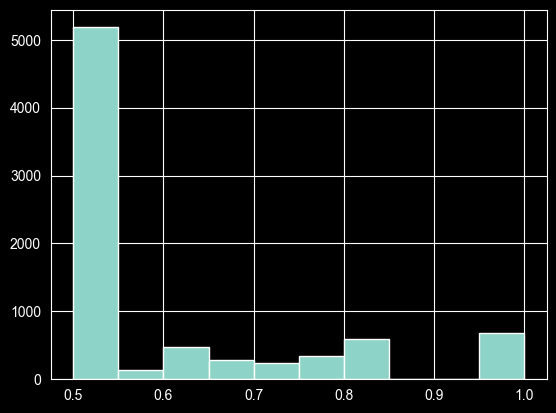

In [89]:
import  matplotlib.pyplot as plt

matches_df['similarity_score'].hist()
plt.show()

In [84]:
# Show examples of matches at different quality levels
print("\n=== TOP 10 BEST MATCHES ===")
top_matches = matches_df.nlargest(10, 'similarity_score')
for _, row in top_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")

print("\n\n=== 10 MEDIAN MATCHES ===")
median_score = matches_df['similarity_score'].median()
median_matches = matches_df.iloc[(matches_df['similarity_score'] - median_score).abs().argsort()[:10]]
for _, row in median_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")

print("\n\n=== 10 WORST MATCHES ===")
worst_matches = matches_df.nsmallest(10, 'similarity_score')
for _, row in worst_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")


=== TOP 10 BEST MATCHES ===

Score: 1.000
  Store 1: M Hoka TORRENT 3 BDVB 10
  Store 2: Hoka Men's Torrent 3 (BDVB) 10 D

Score: 1.000
  Store 1: M Hoka TORRENT 3 BDVB 11
  Store 2: Hoka Men's Torrent 3 (BDVB) 11 D

Score: 1.000
  Store 1: M Hoka TORRENT 3 BDVB 11.5
  Store 2: Hoka Men's Torrent 3 (BDVB) 11 D

Score: 1.000
  Store 1: M Hoka TORRENT 3 BDVB 12
  Store 2: Hoka Men's Torrent 3 (BDVB) 12 D

Score: 1.000
  Store 1: M Hoka TORRENT 3 BDVB 13
  Store 2: Hoka Men's Torrent 3 (BDVB) 13 D

Score: 1.000
  Store 1: W Hoka TORRENT 3 BDVB 7
  Store 2: Hoka Men's Torrent 3 (BDVB) 7 D

Score: 1.000
  Store 1: W Hoka TORRENT 3 BDVB 10
  Store 2: Hoka Men's Torrent 3 (BDVB) 10 D

Score: 1.000
  Store 1: M Hoka Anacapa 2 Low GTX BBLC 12
  Store 2: Hoka Men's Anacapa 2 Low GTX (BBLC) 12 D

Score: 1.000
  Store 1: STANCE WOMEN'S RUN MAKE A MOVE TAB Heather Grey M
  Store 2: Stance Women's Run 4X400 Tab (Grey) MD

Score: 1.000
  Store 1: Roark Ciele x Run Amok Mathis SS Aqua Green XL
  Stor

In [85]:
# Show 20 random examples
print("\n\n=== 20 RANDOM MATCH EXAMPLES ===")
random_matches = matches_df.sample(min(20, len(matches_df)), random_state=42)
for _, row in random_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")



=== 20 RANDOM MATCH EXAMPLES ===

Score: 0.500
  Store 1: M Hoka BONDI 8 WIDE COASTAL SKY / VIBRANT ORANGE 11EE
  Store 2: Hoka Women's SkyFlow (CTF) 8.5 B

Score: 0.500
  Store 1: M Brooks Ghost Max Black/Atomic Blue/Jasmine 4E 11.5
  Store 2: Brooks Men's Ghost Max 060 11.5 4E

Score: 0.500
  Store 1: W New Balance W1080K13 2A 7.5
  Store 2: New Balance W1540GD3 9 B

Score: 0.500
  Store 1: W Hoka BONDI 8 BELLWEATHER BLUE/EVENING SKY 09.5B
  Store 2: Hoka Women's SkyFlow (CMCG) 8.5 B

Score: 0.500
  Store 1: W New Balance W1080K13 2A 5
  Store 2: New Balance W1540GD3 9 B

Score: 0.500
  Store 1: W On Cloudmonster Magnet/Shark 7.5
  Store 2: On Women's Cloudgo (Storm/Magnet) 7.5 B

Score: 0.611
  Store 1: M Brooks Ghost Max Black/Black/Ebony D 13.0
  Store 2: Brooks Men's Ghost Max 060 13 D

Score: 0.500
  Store 1: M Asics Gel-Nimbus 25 Black/Black 10
  Store 2: Asics Gel-Nimbus 22 D 10.5

Score: 0.500
  Store 1: W Saucony Guide 17 BLACK/FOG 05.5
  Store 2: W Saucony Guide 13, 5.5 B